## Imports

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

## Dataset

In [53]:
df=pd.read_csv("/content/MarketPricePrediction.csv")

df.head()

,market,month,year,quantity,priceMin,priceMax,priceMod,state,city,date
0,ABOHAR(PB),January,2005,2350,404,493,446,PB,ABOHAR,January-2005
1,ABOHAR(PB),January,2006,900,487,638,563,PB,ABOHAR,January-2006
2,ABOHAR(PB),January,2010,790,1283,1592,1460,PB,ABOHAR,January-2010
3,ABOHAR(PB),January,2011,245,3067,3750,3433,PB,ABOHAR,January-2011
4,ABOHAR(PB),January,2012,1035,523,686,605,PB,ABOHAR,January-2012


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10227 entries, 0 to 10226
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   market    10227 non-null  object
 1   month     10227 non-null  object
 2   year      10227 non-null  int64 
 3   quantity  10227 non-null  int64 
 4   priceMin  10227 non-null  int64 
 5   priceMax  10227 non-null  int64 
 6   priceMod  10227 non-null  int64 
 7   state     10227 non-null  object
 8   city      10227 non-null  object
 9   date      10227 non-null  object
dtypes: int64(5), object(5)
memory usage: 799.1+ KB


In [55]:
df.describe()

,year,quantity,priceMin,priceMax,priceMod
count,10227.000000,1.022700e+04,10227.000000,10227.000000,10227.000000
mean,2009.022294,7.660488e+04,646.944363,1212.760731,984.284345
std,4.372841,1.244087e+05,673.121850,979.658874,818.471498
min,1996.000000,2.000000e+01,16.000000,145.000000,80.000000
25%,2006.000000,8.898000e+03,209.000000,557.000000,448.000000
50%,2009.000000,2.746000e+04,440.000000,923.000000,747.000000
75%,2013.000000,8.835650e+04,828.000000,1527.000000,1248.000000
max,2016.000000,1.639032e+06,6000.000000,8192.000000,6400.000000


In [56]:
df.nunique()

,0
market,120
month,12
year,21
quantity,8641
priceMin,2026
priceMax,2732
priceMod,2424
state,21
city,117
date,242


In [57]:
df['date'] = pd.to_datetime(df['date'], format='%B-%Y')
df['date'].head()

,date
0,2005-01-01
1,2006-01-01
2,2010-01-01
3,2011-01-01
4,2012-01-01


## EDA

Text(0, 0.5, 'Frequency')

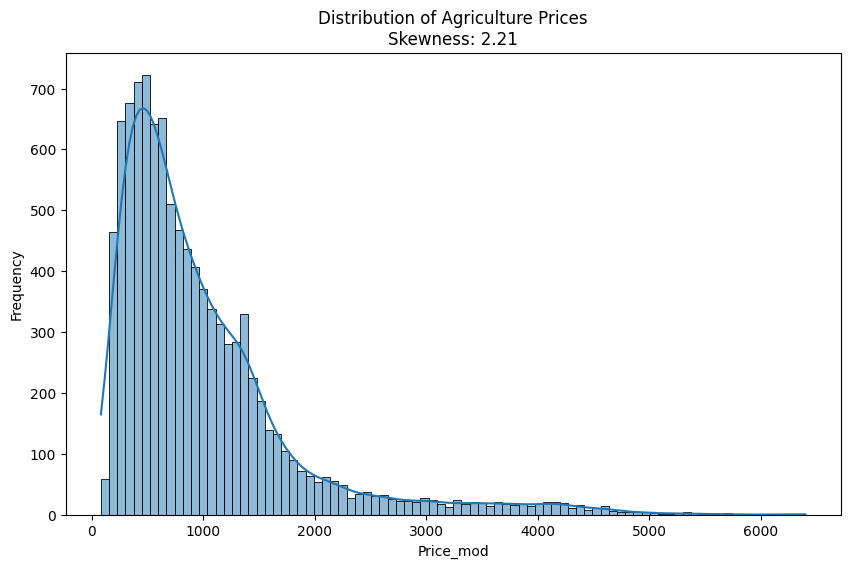

In [58]:
# Plotting the distribution of Price
og_skew = skew(df['priceMod'])
plt.figure(figsize=(10, 6))
sns.histplot(df['priceMod'], kde=True)
plt.title(f'Distribution of Agriculture Prices\nSkewness: {og_skew:.2f}')
plt.xlabel('Price_mod')
plt.ylabel('Frequency')

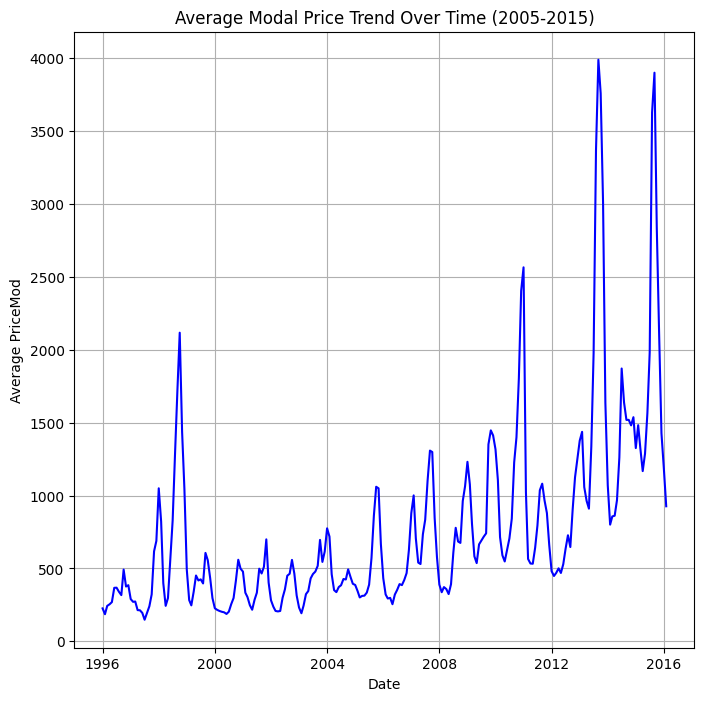

In [59]:
fig, axes = plt.subplots(1, figsize=(8, 8))

# Group by date to get the average price across all markets for that month
monthly_avg = df.groupby('date')['priceMod'].mean()
axes.plot(monthly_avg.index, monthly_avg.values, color='blue')
axes.set_title('Average Modal Price Trend Over Time (2005-2015)')
axes.set_xlabel('Date')
axes.set_ylabel('Average PriceMod')
axes.grid(True)

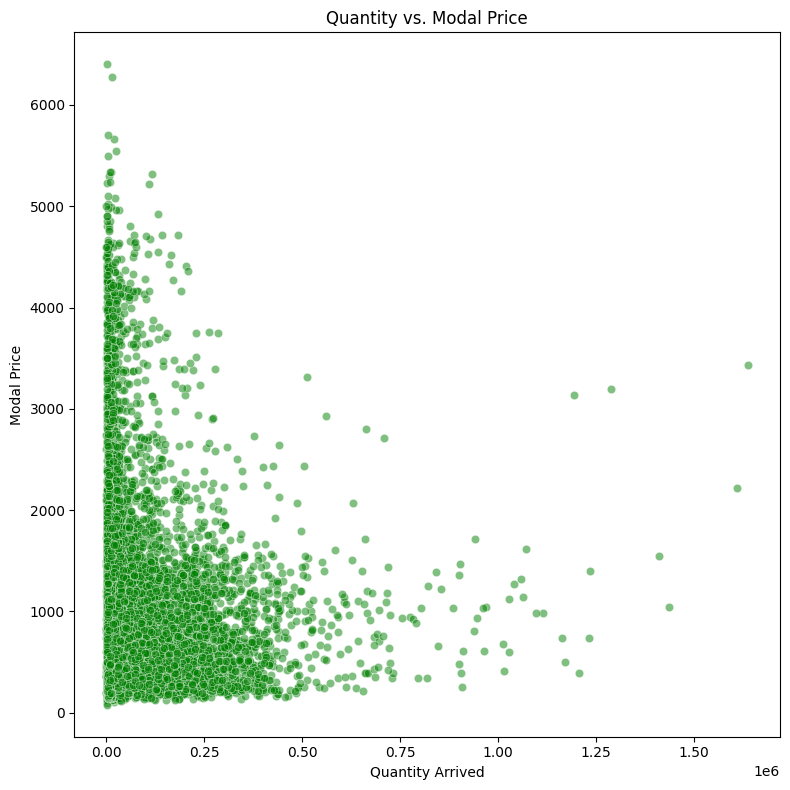

In [60]:
fig, axes = plt.subplots(1, figsize=(8, 8))

sns.scatterplot(x='quantity', y='priceMod', data=df, alpha=0.5, ax=axes, color='green')
axes.set_title('Quantity vs. Modal Price')
axes.set_xlabel('Quantity Arrived')
axes.set_ylabel('Modal Price')
plt.tight_layout()

/tmp/ipython-input-3745065690.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='state', y='priceMod', data=df, ax=ax, palette='viridis')
/tmp/ipython-input-3745065690.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


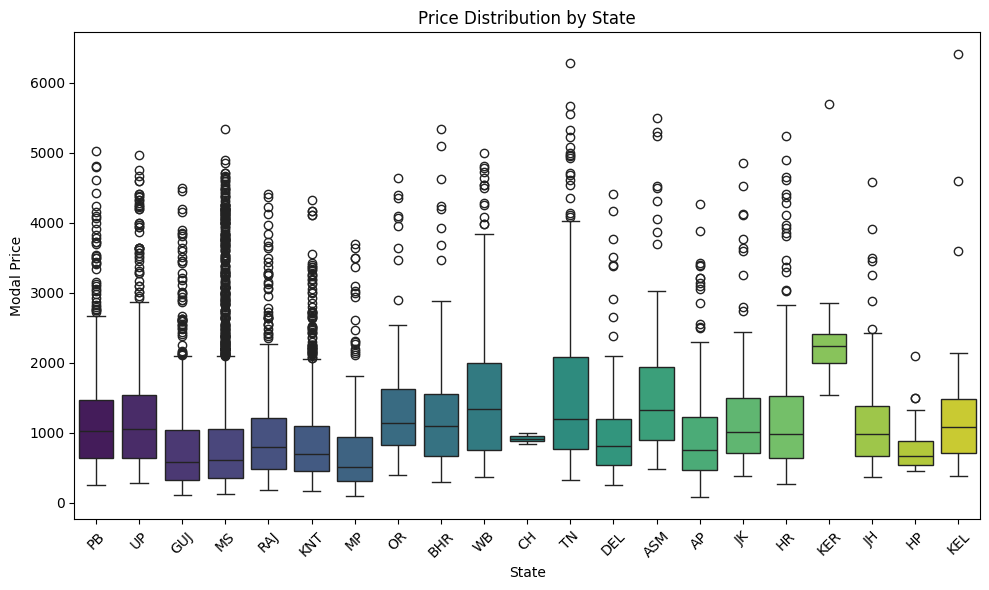

In [61]:
# Plot 3: Boxplot by State
fig, ax = plt.subplots(1, figsize=(10, 6)) # Create a new figure and axes for this plot
sns.boxplot(x='state', y='priceMod', data=df, ax=ax, palette='viridis')
ax.set_title('Price Distribution by State')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_xlabel('State')
ax.set_ylabel('Modal Price')
plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix of Numeric Variables')

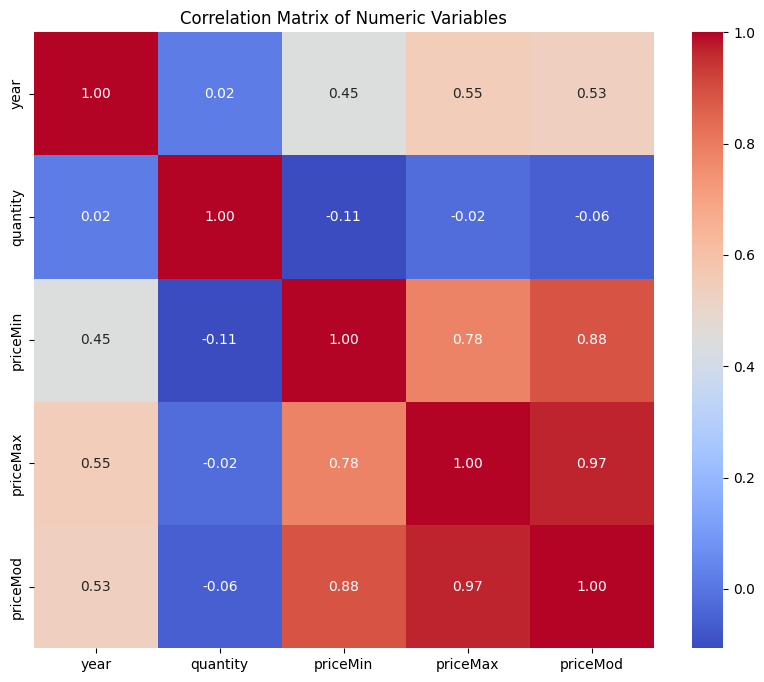

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap((df.select_dtypes(include=['number'])).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")


## Data preprocessoing

In [63]:
df_clean = df.drop(columns=['priceMin', 'priceMax', 'city'])

In [64]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}

df_clean['month'] = df_clean['month'].map(month_map)

In [65]:
df_clean.head()

,market,month,year,quantity,priceMod,state,date
0,ABOHAR(PB),1,2005,2350,446,PB,2005-01-01
1,ABOHAR(PB),1,2006,900,563,PB,2006-01-01
2,ABOHAR(PB),1,2010,790,1460,PB,2010-01-01
3,ABOHAR(PB),1,2011,245,3433,PB,2011-01-01
4,ABOHAR(PB),1,2012,1035,605,PB,2012-01-01


In [66]:
df_encoded = pd.get_dummies(df_clean, columns=['market', 'state'], prefix=['Market', 'State'])

In [67]:
df_encoded.head()

,month,year,quantity,priceMod,date,Market_ABOHAR(PB),Market_AGRA(UP),Market_AHMEDABAD(GUJ),Market_AHMEDNAGAR(MS),Market_AJMER(RAJ),...,State_KER,State_KNT,State_MP,State_MS,State_OR,State_PB,State_RAJ,State_TN,State_UP,State_WB
0,1,2005,2350,446,2005-01-01,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,1,2006,900,563,2006-01-01,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,1,2010,790,1460,2010-01-01,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,1,2011,245,3433,2011-01-01,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,1,2012,1035,605,2012-01-01,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [68]:
df_encoded.shape

(10227, 146)

## Splitting

In [69]:
# Training Data: 2005 to 2012
train_data = df_encoded[df_encoded['year'] <= 2012]
# Testing Data: 2013 to 2015
test_data = df_encoded[df_encoded['year'] > 2012]

In [70]:
X_train = train_data.drop(columns=['priceMod'])
y_train = train_data['priceMod']

X_test = test_data.drop(columns=['priceMod'])
y_test = test_data['priceMod']

In [71]:
print(f"Training Set Shape: {X_train.shape} (Years 2005-2012)")
print(f"Testing Set Shape: {X_test.shape} (Years 2013-2015)")

Training Set Shape: (7497, 145) (Years 2005-2012)
Testing Set Shape: (2730, 145) (Years 2013-2015)
